# Image classification 

For classification purpose, the output layer needs to be a FC layer with its output the class number. 

ViT needs to append a FC layer (head) because its strucute was originally designed for NLP; for other CNN based model, can modify the last layer in-place.

Fine-tuning can:
1. Update the parameters of the whole model
2. Only update the last layer (or certain layers). Can make these parts require_grad=False.

Notes:
1. By default, pretrained PyTorch models (huggingface) are built considering input data (N,C,H,W) as the first layer or embedding layer. Model itself is built with weights only taking a single data (C,H, W) because no need to duplicated the parameters. For example, the ViT model used in this notebook handles batches in the model embedding layer.
2. PyTorch dataloader will prepare data in correct batch (N,C,H,W). Then you can write outputs=model(batch_data). It will feed each data into the "actual" model, calculate the score per data,and ouput the results in batch.
3. Then you can use criterion to calculate a single loss score per minibatch, and update the weights per minibatch (instead of the whole dataset).
4. PyTorch-Lightning handles batch inside the trainer() class.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import os

# Training
## Parameters

In [2]:
# Models to choose from [resnet, alexnet, vgg, squeezenet, densenet, inception]
model_name = 'densenet' #"vit_p32" #"resnet" #"squeezenet"

# Number of classes in the dataset
num_classes = 2

# Batch size during training
batch_size = 16

# Number of epochs to train for 
num_epochs = 100

# Flag for feature extracting. When False, we finetune the whole model, when True we only update the reshaped layer params
feature_extract = True

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

# Decide which device we want to run on
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
print(device)

# output_dir
#round_info= 'round2'
round_info= 'round2'
out_dir = '/lovelace/xiaoya/scientific_txt2image-main/classifier_checkpoints_3p/'+round_info+'/'+model_name+'/'
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

cuda:0


## Dataset

round2 /lovelace/xiaoya/GenAI_dataset/zz_xy_rings_5k_2_1000real_exp_1000fake
263 113


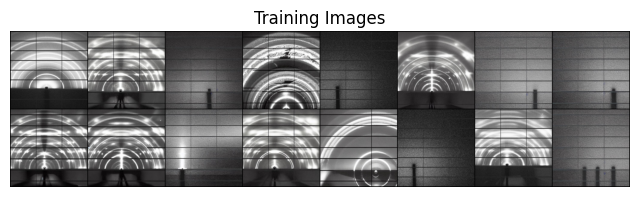

In [3]:
from model_utils import myDataloader


if round_info =='round1':
    dataroot_rings = "/lovelace/xiaoya/GenAI_dataset/generated_and_experimental_data"
    dataroot_peaks = "/lovelace/xiaoya/GenAI_dataset/xc_peaks_5k_1_100fake_100realexp_5th"
    dataroot_empty = "/lovelace/xiaoya/GenAI_dataset/xc_empty_5k_1_100fake_100realexp_1st"
else:
    dataroot_rings = "/lovelace/xiaoya/GenAI_dataset/zz_xy_rings_5k_2_1000real_exp_1000fake"
    dataroot_peaks = "/lovelace/xiaoya/GenAI_dataset/xc_peaks_5k_2_1000fake_1000realexp_4th"
    dataroot_empty = "/lovelace/xiaoya/GenAI_dataset/xc_empty_5k_2_1000fake_1000realexp_3rd"

print(round_info,dataroot_rings)

if model_name =='inception':
    input_size = 299
else:
    input_size = 224
transform=transforms.Compose([transforms.Resize(input_size),
                              transforms.CenterCrop(input_size),
                              transforms.ToTensor(),
                              transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                             ])
dataloaders =  myDataloader(root_rings=dataroot_rings, 
                            root_peaks=dataroot_peaks, 
                            root_empty=dataroot_empty, 
                            batch_size=batch_size, 
                            transform=transform,
                            num_workers = 2,
                            split=[0.7, 0.3],
                            from_subfolders=True)

train_dataloader, val_dataloader = dataloaders.dataloader()
print(len(train_dataloader), len(val_dataloader))
    
dataloaders.plot_dataloader(train_dataloader, device)

# Create training and validation dataloaders
dataloaders_dict = {'train': train_dataloader, 'validation':val_dataloader}


## Training example

In [4]:
from model_utils import myModels

# Initialize the model for this run
model_ft, input_size = myModels.initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

if round_info == 'round2_ft':
    round1_dir = '/lovelace/xiaoya/scientific_txt2image-main/classifier_checkpoints_3p/round1/'+model_name+'/'
    model_ft = torch.load(round1_dir+model_name+'_'+str(num_epochs)+'_epochs_classifier.pth')
    print("use ckpt from round 1:",round1_dir)
# Print the model we just instantiated
#print(model_ft)

# Gather the parameters to be optimized/updated in this run. If we are
#  finetuning we will be updating all parameters. However, if we are 
#  doing feature extract method, we will only update the parameters
#  that we have just initialized, i.e. the parameters with requires_grad is True.
params_to_update = model_ft.parameters()
print("Params to learn:")
if feature_extract:
    params_to_update = []
    for name,param in model_ft.named_parameters():
        if param.requires_grad == True:
            params_to_update.append(param)
            print("\t",name)
else:
    for name,param in model_ft.named_parameters():
        if param.requires_grad == True:
            print("\t",name)

Params to learn:
	 classifier.weight
	 classifier.bias


/home/xiaoya/miniconda3/envs/ensemble_classifier/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/xiaoya/miniconda3/envs/ensemble_classifier/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
from pipeline_utils import Trainer

# define optimizer and loss
optimizer_ft = optim.SGD(params_to_update, lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

# Train and evaluate
trainer = Trainer(model_ft, 
                  dataloaders_dict, 
                  criterion, 
                  optimizer_ft,
                  device=device, 
                  num_epochs=num_epochs, 
                  is_inception=(model_name=="inception"), 
                  verbose=True
                  )
model_ft, hist = trainer.train()

Epoch 0/999
----------


100%|█████████████████████████████████████████| 263/263 [00:15<00:00, 17.18it/s]


train loss: 0.3794 acc: 0.8493


100%|█████████████████████████████████████████| 113/113 [00:05<00:00, 19.09it/s]


validation loss: 0.3606 acc: 0.8578
Epoch 1/999
----------


...

validation loss: 0.2166 acc: 0.9150
Epoch 999/999
----------


100%|█████████████████████████████████████████| 263/263 [00:12<00:00, 20.27it/s]


train loss: 0.1457 acc: 0.9460


100%|█████████████████████████████████████████| 113/113 [00:05<00:00, 19.43it/s]

validation loss: 0.2162 acc: 0.9172

Training complete in 314m 16s
Best val Acc: 0.918889


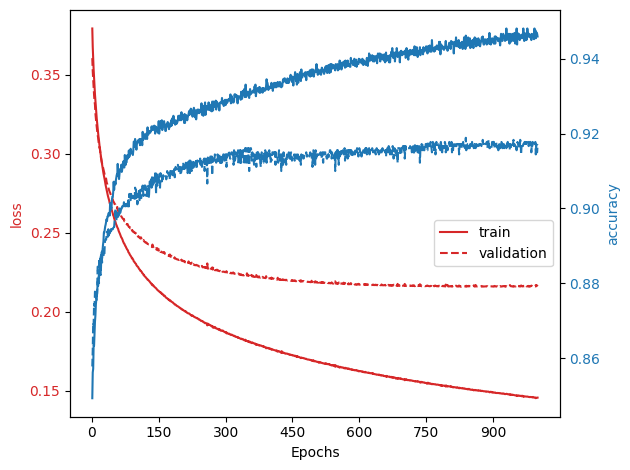

In [6]:
trainer.plot_history(10, save_fig=True, out_name=out_dir+'history_'+model_name+'_'+str(num_epochs)+'epochs_classifier.png')
trainer.save_results(out_dir, model_name=model_name+'_'+str(num_epochs)+'_epochs_classifier')

# Evaluation example (vit_16x16)

In [5]:
import torchvision
from pipeline_utils import Evaluation
from torch.utils.data import ConcatDataset
testroot_rings = "/lovelace/xiaoya/GenAI_dataset/xc_ring_1k_0_100_2nd_corrected"
testroot_peaks = "/lovelace/xiaoya/GenAI_dataset/xc_peaks_5k_0_100_1st"
testroot_empty =  "/lovelace/xiaoya/GenAI_dataset/xc_empty_5k_0_100_1st"
dataset_rings = torchvision.datasets.ImageFolder(root=testroot_rings, transform=transform)
dataset_peaks = torchvision.datasets.ImageFolder(root=testroot_peaks, transform=transform)
dataset_empty = torchvision.datasets.ImageFolder(root=testroot_empty, transform=transform)
dataset = ConcatDataset([dataset_rings,dataset_peaks,dataset_empty])

eval_dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
print(len(eval_dataloader))

38


In [6]:
vit_p16 = torch.load(out_dir+model_name+'_'+str(num_epochs)+'_epochs_classifier.pth')
vit_p16_eval = Evaluation(vit_p16, eval_dataloader, threshold=0.5, device=device)
print(out_dir+model_name+'_'+str(num_epochs)+'_epochs_classifier.pth')
vit_p16_eval.evaluate()

/lovelace/xiaoya/scientific_txt2image-main/classifier_checkpoints_3p/round2/densenet/densenet_100_epochs_classifier.pth


100%|███████████████████████████████████████████| 38/38 [00:04<00:00,  7.70it/s]

avg acc: 0.8366667032241821, prec: 0.8506944179534912


In [ ]:
#weights =[0.7,0.8,0.3,0.1,0.3,0.3,0.4,0.2]